# Authorship analysis

## Overview

Analyses authorship of the non-conceptual papers in `data-clean/all-data.csv`, in particular the overlap of authors between the AGILE and GIScience conference series.

For every paper we resolve the DOI from the `link` column and query **OpenAlex** (via `pyalex`) to obtain authors and their ORCIDs. Authors are then reconciled across papers, preferring ORCID over author name (so that a person who changed their name is still matched to a single identity), with a normalised-name fallback for authors without an ORCID.

OpenAlex misses a handful of registered DOIs (notably Dagstuhl LIPIcs entries). For those we fall back to an OpenAlex title search (checking the work's `locations[]` list for parallel hostings) and, as a last resort, to scraping schema.org `ScholarlyArticle` metadata from the publisher landing page HTML head.

Conceptual papers (`consolidated_cp == True`) are excluded.

Raw JSON responses are cached under `data/authorship-cache/` to keep re-runs cheap; the cache is git-ignored.

Temporal analyses (year-by-year same-conference overlap, reproducibility trends for cross-conference-author papers, and the cross-group non-independence check) are in [`09_authorship-historic.ipynb`](09_authorship-historic.ipynb), which reads `data-clean/authors.csv` produced by this notebook.

**Note**: This notebook was largely co-edited with Claude Code. All code snippets and data were inspected thoroughly by a contributing author and checked for correctness.

## Related work

Keßler, Janowicz, and Kauppinen explored the GIScience research field through linked data built from conference metadata:

> *spatial@linkedscience -- Exploring the Research Field of GIScience with Linked Data*, GIScience 2012 (LNCS 7478), [doi:10.1007/978-3-642-33024-7_8](https://doi.org/10.1007/978-3-642-33024-7_8).

That work established a linked-data view of the community that complements the paper-level authorship reconciliation pursued here.

## 1. Setup

All dependencies are declared in [`04_environment.yml`](04_environment.yml): the conda packages `matplotlib-base`, `matplotlib-venn`, and `requests` (already present from the base env), plus `pyalex` via pip.

Helper functions live in [`authorship_utils.py`](authorship_utils.py) next to this notebook. The helper functions include DOI extraction, OpenAlex fetching with on-disk caching, schema.org JSON-LD landing-page fallback, title similarity, author normalisation, and identity resolution.

In [46]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyalex
from matplotlib_venn import venn2

import authorship_utils as au

USER_AGENT_EMAIL = "daniel.nuest@tu-dresden.de"
pyalex.config.email = USER_AGENT_EMAIL

USER_AGENT = (
    f"reproducible-research-giscience-longitudinal-study/1.0 (mailto:{USER_AGENT_EMAIL})"
)

INPUT_CSV = "data-clean/all-data.csv"
CACHE_DIR = Path("data/authorship-cache")
OPENALEX_CACHE = CACHE_DIR / "openalex"
OPENALEX_CACHE.mkdir(parents=True, exist_ok=True)

FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_colwidth", 120)

## 2. Load and filter papers

Drop conceptual papers based on `consolidated_cp == False`.

In [47]:
df_all = pd.read_csv(INPUT_CSV)
df = df_all[df_all["consolidated_cp"] == False].copy().reset_index(drop=True)
print(f"total papers: {len(df_all)}")
print(f"non-conceptual papers analysed: {len(df)}")
print(df.groupby("conf").size())

total papers: 224
non-conceptual papers analysed: 203
conf
agile        130
giscience     73
dtype: int64


## 3. Resolve DOIs from the `link` column

The `link` column contains a mix of forms:

- `https://doi.org/...` > use directly.
- Springer `.../chapter/10.XXXX/...` > the DOI is the tail starting at `10.`.
- Copernicus `agile-giss.copernicus.org/articles/{vol}/{art}/{year}/` > assemble
  `10.5194/agile-giss-{vol}-{art}-{year}`.
- Dagstuhl `drops.dagstuhl.de/.../LIPIcs.GIScience.{year}.{n}/...` > assemble
  `10.4230/LIPIcs.GIScience.{year}.{n}`.
- Anything else is logged as unresolved.

In [48]:
df["doi"] = df["link"].map(au.extract_doi)
missing = df[df["doi"].isna()][["paper", "link"]]
print(f"DOIs resolved: {df['doi'].notna().sum()} / {len(df)}")
if not missing.empty:
    print("\nUnresolved links:")
    display(missing)

DOIs resolved: 203 / 203


## 4. Fetch metadata from OpenAlex

Each paper's JSON payload is cached on disk so re-runs are offline. Delete `data/authorship-cache/` to force a refresh.

OpenAlex fetches try, in order:

1. **Direct DOI lookup** via `pyalex.Works()[doi_url]`.
2. **Title-search fallback** when (1) returns 404, accepting a candidate if its primary DOI matches, if the registered DOI appears in the candidate's `locations[]` list (parallel hostings: preprints, repositories, re-publications), or if title similarity and year match strongly.
3. **Landing-page JSON-LD scrape** when (2) also fails, parsing the publisher's schema.org `ScholarlyArticle` metadata from `<script type="application/ld+json">`. This covers the cases where a DOI is not indexed by OpenAlex at all (e.g. Dagstuhl LIPIcs pages serve rich schema.org metadata including ORCIDs as `sameAs`).

Transient API errors are retried a few times before giving up.

In [49]:
# Thin wrapper binds the fetch helper to this notebook's cache dir and user agent.
def fetch_openalex(doi, title, year):
    return au.fetch_openalex(
        doi, OPENALEX_CACHE,
        expected_title=title, expected_year=year,
        landing_page_url=f"https://doi.org/{doi}",
        landing_page_user_agent=USER_AGENT,
    )

In [50]:
openalex_data: dict[str, dict] = {}

for i, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    if i % 25 == 0:
        print(f"[{i+1}/{len(df)}] {row['paper']} -> {doi}")
    openalex_data[doi] = fetch_openalex(doi, row["title"], int(row["year"])) or {}

oa_found = sum(1 for v in openalex_data.values() if v and not v.get("_not_found"))
recovered = sum(1 for v in openalex_data.values() if v and v.get("_recovered_via"))
print(f"\nOpenAlex hits: {oa_found} / {len(openalex_data)}  (of which {recovered} via fallback)")

recovered_rows = [
    {"doi": doi, "recovered_via": v.get("_recovered_via"), "openalex_doi": v.get("doi")}
    for doi, v in openalex_data.items()
    if v and v.get("_recovered_via")
]
if recovered_rows:
    display(pd.DataFrame(recovered_rows))

[1/203] agile_2017_006 -> 10.1007/978-3-319-56759-4_6
[26/203] giscience_2021_024 -> 10.4230/lipics.giscience.2021.ii.8
[51/203] giscience_2021_017 -> 10.4230/lipics.giscience.2021.ii.1
[76/203] giscience_2021_019 -> 10.4230/lipics.giscience.2021.ii.3
[101/203] giscience_2021_014 -> 10.4230/lipics.giscience.2021.i.14
[126/203] giscience_2018_015 -> 10.4230/LIPIcs.GIScience.2018.15
[151/203] giscience_2021_012 -> 10.4230/lipics.giscience.2021.i.12
[176/203] giscience_2021_029 -> 10.4230/lipics.giscience.2021.ii.13
[201/203] giscience_2021_018 -> 10.4230/lipics.giscience.2021.ii.2

OpenAlex hits: 203 / 203  (of which 11 via fallback)


,doi,recovered_via,openalex_doi
0,10.5194/agile-giss-4-3-2023,doi-exact,https://doi.org/10.5194/agile-giss-4-3-2023
1,10.4230/LIPIcs.GIScience.2018.8,doi-exact,https://doi.org/10.4230/lipics.giscience.2018.8
2,10.4230/lipics.giscience.2021.i.17,doi-exact,https://doi.org/10.4230/lipics.giscience.2021.i.17
3,10.4230/lipics.giscience.2021.i.2,landing-page-jsonld,https://doi.org/10.4230/lipics.giscience.2021.i.2
4,10.5194/agile-giss-1-2-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-2-2020
5,10.4230/lipics.giscience.2021.i.6,doi-in-locations,https://doi.org/10.4230/lipics.cosit.2022.1
6,10.5194/agile-giss-3-3-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-3-2022
7,10.5194/agile-giss-3-19-2022,doi-exact,https://doi.org/10.5194/agile-giss-3-19-2022
8,10.4230/lipics.giscience.2021.i.4,doi-in-locations,https://doi.org/10.20944/preprints202002.0326.v1
9,10.5194/agile-giss-1-12-2020,doi-exact,https://doi.org/10.5194/agile-giss-1-12-2020


## 5. Verify paper title against OpenAlex

Fuzzy match on lowercased, punctuation-stripped titles to make sure the DOI we resolved points to the same paper. Any similarity below 0.80 is flagged. The recorded `title` in `all-data.csv` is the authoritative source still.

In [51]:
verify_rows = []
for _, row in df.iterrows():
    doi = row["doi"]
    if not doi:
        continue
    oa = openalex_data.get(doi) or {}
    oa_title = au.openalex_title(oa)
    verify_rows.append(
        {
            "paper": row["paper"],
            "title": row["title"],
            "doi": doi,
            "openalex_title": oa_title,
            "sim_openalex": au.title_similarity(row["title"], oa_title),
        }
    )

verify_df = pd.DataFrame(verify_rows)
low_match = verify_df[verify_df["sim_openalex"] < 0.80]
print(f"Titles with similarity <0.80: {len(low_match)} / {len(verify_df)}")
display(low_match.sort_values("sim_openalex"))

Titles with similarity <0.80: 1 / 203


,paper,title,doi,openalex_title,sim_openalex
116,agile_2022_011,Machine Learning with Kay,10.5194/agile-giss-3-11-2022,Machine Learning with &amp;lt;i&amp;gt;Kay&amp;lt;/i&amp;gt;,0.609756


The paper "Machine Learning with Kay" is identified because of HTML code artifacts `&amp;lt...` in the title on OpenAlex.

## 6. Extract authors and ORCIDs

Per paper we read the OpenAlex `authorships[]` list in its native order, capturing the display
name and ORCID (if any) for each author.

In [52]:
author_rows = []

for _, row in df.iterrows():
    doi = row["doi"]
    oa_list = au.openalex_authors(openalex_data.get(doi) or {})
    for position, a in enumerate(oa_list, start=1):
        author_rows.append(
            {
                "paper": row["paper"],
                "conf": row["conf"],
                "year": row["year"],
                "doi": doi,
                "position": position,
                "name": a["name"],
                "orcid": a["orcid"],
            }
        )

authors_df = pd.DataFrame(author_rows)
print(f"author-paper rows: {len(authors_df)}")
print(f"papers with at least one author: {authors_df['paper'].nunique()}")
print(
    f"ORCID coverage: {authors_df['orcid'].notna().sum()} / {len(authors_df)} "
    f"({authors_df['orcid'].notna().mean():.1%})"
)

author-paper rows: 715
papers with at least one author: 203
ORCID coverage: 571 / 715 (79.9%)


## 7. Build author identities

ORCID is preferred (covers name changes). For authors without an ORCID in the OpenAlex record, we use a normalised-name key.

A second pass then upgrades name-only identities to ORCID identities whenever an ORCID row for the same normalised name exists somewhere in the corpus. This fixes the common case of an author appearing as ORCID-tagged on one paper and untagged on another. When two
different ORCIDs share a normalised name (i.e. genuine namesakes), the merge is skipped to avoid collapsing two different people.

The remaining pure name-only identities can still split a single person who appears under different name spellings, and can conflate two people with identical names. Both are reported in the counts below so readers can reason about the error bar. The counts also report manual resolutions that are in effect (see next section).

In [53]:
# Two-pass identity resolution:
# 1. ORCID-first identity per row (from OpenAlex).
# 2. Post-hoc merge: upgrade name-only identities to ORCID identities when an ORCID row
#    for the same normalised name exists in the corpus, OR when a manual decision
#    has been recorded in data/orcid-resolutions.csv (see the optional cell below).
ORCID_DECISIONS = Path("data/orcid-resolutions.csv")
decisions_df = pd.read_csv(ORCID_DECISIONS) if ORCID_DECISIONS.exists() else None

authors_df["identity"] = au.merge_name_only_identities(
    authors_df["orcid"], authors_df["name"], manual_resolutions=decisions_df,
)

id_to_name = (
    authors_df.groupby("identity")["name"]
    .agg(lambda s: Counter(s).most_common(1)[0][0])
    .to_dict()
)

n_total = authors_df["identity"].nunique()
n_orcid = sum(1 for i in authors_df["identity"].unique() if i.startswith("orcid:"))
n_name = n_total - n_orcid
n_manual = (decisions_df["chosen_orcid"].astype(str).str.upper() != "NONE").sum() if decisions_df is not None else 0
print(f"distinct author identities: {n_total}")
print(f"  - with ORCID (incl. merged name-only rows): {n_orcid}")
print(f"  - name-fallback only:                        {n_name}")
print(f"  - manual resolutions in effect:              {n_manual}")

distinct author identities: 519
  - with ORCID (incl. merged name-only rows): 425
  - name-fallback only:                        94
  - manual resolutions in effect:              23


### Optional: resolve remaining name-only identities against ORCID

Many remaining name-only identities are people who simply did not list an ORCID on a particular paper. The workflow below queries the **ORCID public API** for matching profiles and allows to attach each name to a specific ORCID (or mark it explicitly as "no match"). Decisions are stored in [`data/orcid-resolutions.csv`](data/orcid-resolutions.csv); the file is committed to git so resolutions are persistent and consulted by the identity-merge cell above on every subsequent run.

The review is split into two non-blocking notebook cells (with a manual edit step in between) so it works in different Jupyter frontends:

1. **Prepare & display.** The first cell queries ORCID for every undecided name-only identity, writes a CSV template at [`data/orcid-candidates.csv`](data/orcid-candidates.csv), and renders each queue item as Markdown with **clickable DOI links** (analyst can open
   the landing page of every paper the author appears on in our corpus, alongside the paper title) and **clickable ORCID links** (so analyst can open each candidate profile directly). Each candidate is prefixed with its 1-based index `[1]`, `[2]`, ... for the following interaction.
2. **Record decisions.** Edit `data/orcid-candidates.csv` in-place: set the `chosen_orcid` column to one of

   - a **1-based candidate index** (`1`, `2`, ...) -- easiest to type when picking from the rendered list above; the apply cell looks the index up in the row's `candidate_orcids` column and records the corresponding full ORCID,
   - a **full ORCID** (`0000-0001-2345-6789`) -- equivalent, useful when copy-pasting from an external source (e.g. from the ORCID profile page you opened via the clickable link),
   - `NONE` -- no match (prevents re-querying on the next run),
   - leave blank -- skip for now (row stays in the template and re-appears next run).

   Optional free-text in `notes`. Invalid values (e.g., an out-of-range index or a malformed ORCID) are rejected by the apply cell with a clear error, so typos can't be silently recorded as a decision.
   
   3. **Apply.** The second cell validates the template, appends the decisions to `data/orcid-resolutions.csv`, then re-run the identity cell above to apply them. Rows whose `name_key` is already present in the decisions file are skipped, so the apply cell is safe to re-run.

The whole block does nothing unless `RUN_ORCID_RESOLUTION` is `True`, because the manual edit step should not run during automated notebook execution.

In [54]:
RUN_ORCID_RESOLUTION = True  # set to False to skip the ORCID review entirely
ORCID_CANDIDATES = Path("data/orcid-candidates.csv")

# Step 1 of 3: build the queue and render it with clickable DOI and ORCID links.
# This cell is safe to re-run -- partially filled-in values in orcid-candidates.csv
# are preserved when the template is regenerated.
if RUN_ORCID_RESOLUTION:
    orcid_queue = au.prepare_orcid_resolution(
        authors_df,
        df,                       # papers_df: provides the paper titles for display
        decisions_path=ORCID_DECISIONS,
        candidates_path=ORCID_CANDIDATES,
        user_agent=USER_AGENT,
        cache_dir=CACHE_DIR,      # caches ORCID API responses under data/authorship-cache/orcid/
        only_cross_year=False,     # set False to walk every name-only identity
    )
    au.display_orcid_resolution(orcid_queue, candidates_path=ORCID_CANDIDATES)

*Nothing to resolve — all eligible name-only identities already have a recorded decision.*

In [55]:
# Step 3 of 3: apply the decisions you entered into data/orcid-candidates.csv.
# Reads the template, validates each `chosen_orcid` (ORCID or 'NONE'), and appends
# to data/orcid-resolutions.csv. Idempotent -- rows already in the decisions file
# are skipped. Re-run the identity cell above afterwards to merge the new resolutions.
if RUN_ORCID_RESOLUTION and ORCID_CANDIDATES.exists():
    au.apply_orcid_resolutions(ORCID_CANDIDATES, ORCID_DECISIONS)

applied 0 new decision(s); 0 row(s) left unresolved (blank `chosen_orcid` — kept in orcid-candidates.csv); 0 row(s) already in the decisions file; decisions file now has 117 total row(s).


## 8. Cross-conference author overlap

This part treats each conference as a single set of author identities pooled across **all** years in the corpus. Results here answer *"how much does the AGILE author community overlap with the GIScience author community at all, irrespective of timing?"*. Temporal dynamics are covered in [`09_authorship-historic.ipynb`](09_authorship-historic.ipynb).

### 8.1 Distinct authors per conference and the intersection

In [56]:
agile_ids = set(authors_df[authors_df["conf"] == "agile"]["identity"])
gis_ids = set(authors_df[authors_df["conf"] == "giscience"]["identity"])
both_ids = agile_ids & gis_ids

print(f"AGILE-only authors:     {len(agile_ids - gis_ids)}")
print(f"GIScience-only authors: {len(gis_ids - agile_ids)}")
print(f"In both conferences:    {len(both_ids)}")

both_orcid = {i for i in both_ids if i.startswith("orcid:")}
both_name = both_ids - both_orcid
print(
    f"  of which matched by ORCID:        {len(both_orcid)}"
)
print(
    f"  of which matched by name-fallback: {len(both_name)}  (interpret with care)"
)

AGILE-only authors:     314
GIScience-only authors: 167
In both conferences:    38
  of which matched by ORCID:        37
  of which matched by name-fallback: 1  (interpret with care)


### 8.2 Figure 1: Venn diagram

Distinct author identities per conference, pooled across all years.

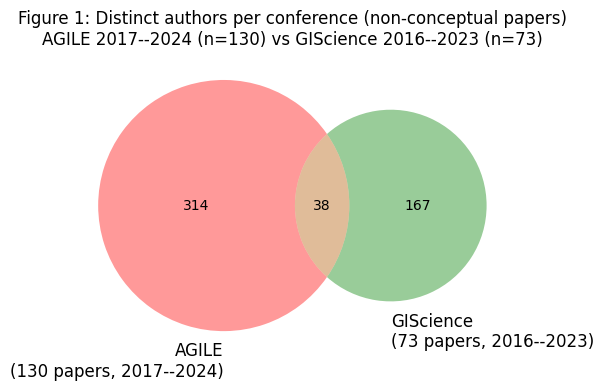

In [57]:
ag_papers = df[df["conf"] == "agile"]
gi_papers = df[df["conf"] == "giscience"]
ag_range = f"{int(ag_papers['year'].min())}--{int(ag_papers['year'].max())}"
gi_range = f"{int(gi_papers['year'].min())}--{int(gi_papers['year'].max())}"

fig, ax = plt.subplots(figsize=(6, 5.4))
venn2(
    [agile_ids, gis_ids],
    set_labels=(
        f"AGILE\n({len(ag_papers)} papers, {ag_range})",
        f"GIScience\n({len(gi_papers)} papers, {gi_range})",
    ),
    ax=ax,
)
ax.set_title(
    f"Figure 1: Distinct authors per conference (non-conceptual papers)\n"
    f"AGILE {ag_range} (n={len(ag_papers)}) vs GIScience {gi_range} (n={len(gi_papers)})"
)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1_authorship_venn.png", dpi=150)
fig.savefig(FIG_DIR / "figure1_authorship_venn.pdf")
plt.show()

### 8.3 Papers with at least one cross-conference author

For each paper, check whether any of its authors also appears on **any** paper at the other conference series in any year. This is the corpus-wide, time-agnostic count. Reported for the whole corpus, per-conference.

In [58]:
# Map each identity to the set of conferences it appears in.
identity_confs = (
    authors_df.groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)

# ORCID-only identities (drop name-fallback authors entirely).
orcid_identity_confs = (
    authors_df[authors_df["orcid"].notna()]
    .groupby("identity")["conf"].agg(lambda s: set(s)).to_dict()
)


def paper_cross_conf(paper_df: pd.DataFrame, identity_map: dict) -> pd.Series:
    per_paper = {}
    for paper, grp in paper_df.groupby("paper"):
        this_conf = grp["conf"].iloc[0]
        cross = any(
            (identity_map.get(ident, set()) - {this_conf})
            for ident in grp["identity"]
        )
        per_paper[paper] = cross
    return pd.Series(per_paper, name="cross_conf")


cross_any = paper_cross_conf(authors_df, identity_confs)
cross_orcid = paper_cross_conf(
    authors_df[authors_df["orcid"].notna()], orcid_identity_confs
)

paper_conf = authors_df.groupby("paper")["conf"].first()


def summarise(series: pd.Series, label: str) -> None:
    df_ = series.to_frame().join(paper_conf)
    total = len(df_)
    n_cross = int(df_["cross_conf"].sum())
    print(f"[{label}] overall: {n_cross} / {total} papers have >=1 cross-conference author")
    for conf, sub in df_.groupby("conf"):
        print(
            f"  {conf:>9}: {int(sub['cross_conf'].sum())} / {len(sub)} "
            f"({sub['cross_conf'].mean():.1%})"
        )


summarise(cross_any, "any identity (ORCID + name-fallback)")
print()
summarise(cross_orcid, "ORCID-only")

[any identity (ORCID + name-fallback)] overall: 79 / 203 papers have >=1 cross-conference author
      agile: 46 / 130 (35.4%)
  giscience: 33 / 73 (45.2%)

[ORCID-only] overall: 73 / 199 papers have >=1 cross-conference author
      agile: 43 / 129 (33.3%)
  giscience: 30 / 70 (42.9%)


### 8.4 Cross-conference authors: paper counts per conference

List every author in both conferences over the whole corpus with the number of papers at each and the list of years they appear in.

In [59]:
overlap_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    overlap_rows.append(
        {
            "name": id_to_name[ident],
            "identity": ident,
            "orcid": ident.split(":", 1)[1] if ident.startswith("orcid:") else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "years": ",".join(str(y) for y in sorted(sub["year"].unique())),
        }
    )

overlap_df = (
    pd.DataFrame(overlap_rows)
    .sort_values(["total_papers", "name"], ascending=[False, True])
    .reset_index(drop=True)
)
display(overlap_df)

,name,identity,orcid,agile_papers,giscience_papers,total_papers,years
0,Ioannis Giannopoulos,orcid:0000-0002-2556-5230,0000-0002-2556-5230,5,6,11,"2016,2018,2019,2020,2021,2023,2024"
1,Martin Raubal,orcid:0000-0001-5951-6835,0000-0001-5951-6835,7,4,11,"2016,2017,2018,2019,2020,2021,2022,2023"
2,Krzysztof Janowicz,orcid:0009-0003-1968-887X,0009-0003-1968-887X,8,2,10,"2017,2018,2019,2020,2021,2022"
3,Henry Martin,orcid:0000-0002-0456-8539,0000-0002-0456-8539,5,3,8,"2018,2019,2020,2021,2022,2023"
4,Dominik Bucher,orcid:0000-0001-9824-5388,0000-0001-9824-5388,3,3,6,"2018,2019,2020,2021"
5,Gengchen Mai,orcid:0000-0002-7818-7309,0000-0002-7818-7309,5,1,6,"2018,2019,2020,2021,2022"
6,Carsten Keßler,orcid:0000-0002-9724-820X,0000-0002-9724-820X,4,1,5,"2016,2018,2019,2020,2022"
7,Jan‐Henrik Haunert,orcid:0000-0001-8005-943X,0000-0001-8005-943X,1,4,5,"2016,2018,2020,2021"
8,Markus Kattenbeck,orcid:0000-0001-6028-0428,0000-0001-6028-0428,1,4,5,"2018,2020,2021"
9,Stephan Winter,orcid:0000-0002-3403-6939,0000-0002-3403-6939,4,1,5,"2017,2019,2020,2023"


### 8.5 Detailed cross-conference author statistics

For every author that appears in **both** conferences over the whole corpus, show how many papers they co-authored at each event series, their first and last year in the corpus, and the span of years covered. Names in parentheses indicate identities matched via the normalised-name fallback (no ORCID); treat those rows with extra care because name collisions and name-variant splits are possible.

In [60]:
cross_stats_rows = []
for ident in both_ids:
    sub = authors_df[authors_df["identity"] == ident]
    years = sorted(sub["year"].unique())
    is_orcid = ident.startswith("orcid:")
    display_name = id_to_name[ident] if is_orcid else f"({id_to_name[ident]})"
    cross_stats_rows.append(
        {
            "name": display_name,
            "orcid": ident.split(":", 1)[1] if is_orcid else None,
            "agile_papers": sub[sub["conf"] == "agile"]["paper"].nunique(),
            "giscience_papers": sub[sub["conf"] == "giscience"]["paper"].nunique(),
            "total_papers": sub["paper"].nunique(),
            "first_year": int(years[0]),
            "last_year": int(years[-1]),
            "year_span": int(years[-1] - years[0]),
            "match": "orcid" if is_orcid else "name",
        }
    )

cross_stats_df = (
    pd.DataFrame(cross_stats_rows)
    .sort_values(
        ["total_papers", "agile_papers", "giscience_papers", "name"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

print(
    f"cross-conference authors: {len(cross_stats_df)} "
    f"(orcid-matched: {(cross_stats_df['match']=='orcid').sum()}, "
    f"name-matched: {(cross_stats_df['match']=='name').sum()})"
)
display(cross_stats_df)

cross_stats_df.to_csv("data/authors-cross-conference.csv", index=False)
print("wrote data/authors-cross-conference.csv")

cross-conference authors: 38 (orcid-matched: 37, name-matched: 1)


,name,orcid,agile_papers,giscience_papers,total_papers,first_year,last_year,year_span,match
0,Martin Raubal,0000-0001-5951-6835,7,4,11,2016,2023,7,orcid
1,Ioannis Giannopoulos,0000-0002-2556-5230,5,6,11,2016,2024,8,orcid
2,Krzysztof Janowicz,0009-0003-1968-887X,8,2,10,2017,2022,5,orcid
3,Henry Martin,0000-0002-0456-8539,5,3,8,2018,2023,5,orcid
4,Gengchen Mai,0000-0002-7818-7309,5,1,6,2018,2022,4,orcid
5,Dominik Bucher,0000-0001-9824-5388,3,3,6,2018,2021,3,orcid
6,Carsten Keßler,0000-0002-9724-820X,4,1,5,2016,2022,6,orcid
7,Stephan Winter,0000-0002-3403-6939,4,1,5,2017,2023,6,orcid
8,Jan‐Henrik Haunert,0000-0001-8005-943X,1,4,5,2016,2021,5,orcid
9,Markus Kattenbeck,0000-0001-6028-0428,1,4,5,2018,2021,3,orcid


wrote data/authors-cross-conference.csv


## 9. Persist enriched outputs

The authoritative per-author-per-paper table is written to [`data-clean/authors.csv`](data-clean/authors.csv). This is the curated table for downstream use, and its schema is documented in [`data-clean/README.md`](data-clean/README.md).

Derived / aggregate views, useful for the manuscript and quick re-use but trivially regenerable from `authors.csv`, land in [`data/`](data/):

- `authors-overlap.csv`            -- cross-conference authors with paper counts and years (A.4).
- `authors-cross-conference.csv`   -- detailed cross-conference statistics including year span (A.5).
- `authors-title-verification.csv` -- DOI-vs-OpenAlex title sanity check (debug artifact).

Temporal and reproducibility analyses (year-by-year overlap, reproducibility by cross-author subset, cross-group non-independence) are in [`09_authorship-historic.ipynb`](09_authorship-historic.ipynb), which reads `data-clean/authors.csv` as its input.

In [61]:
# Authoritative table: one row per author-paper.
authors_df.to_csv("data-clean/authors.csv", index=False)
print("wrote data-clean/authors.csv (authoritative)")

# Derived / aggregate views (regenerable from authors.csv).
overlap_df.to_csv("data/authors-overlap.csv", index=False)
verify_df.to_csv("data/authors-title-verification.csv", index=False)
print("wrote data/authors-overlap.csv")
print("wrote data/authors-title-verification.csv")

wrote data-clean/authors.csv (authoritative)
wrote data/authors-overlap.csv
wrote data/authors-title-verification.csv
